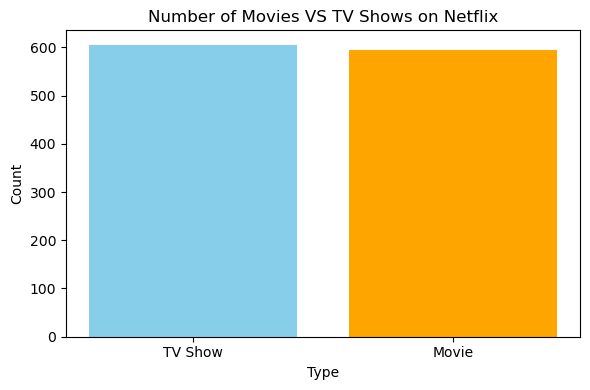

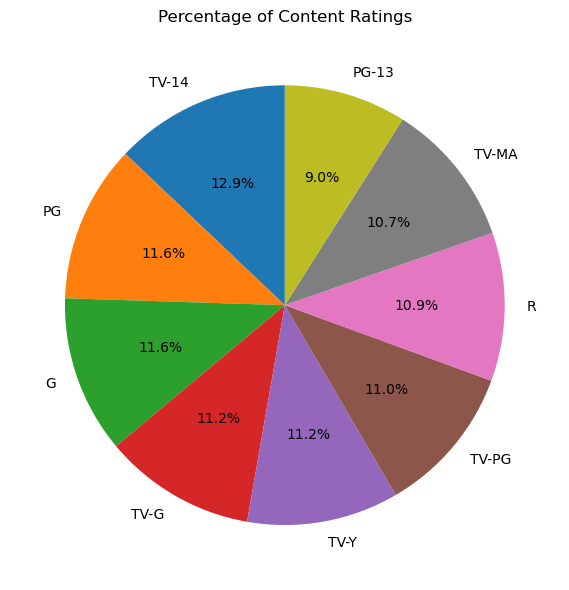

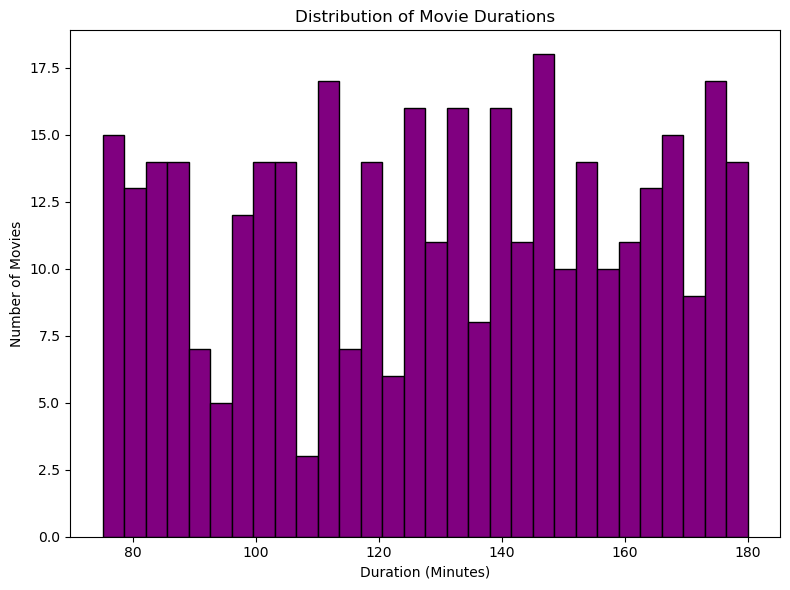

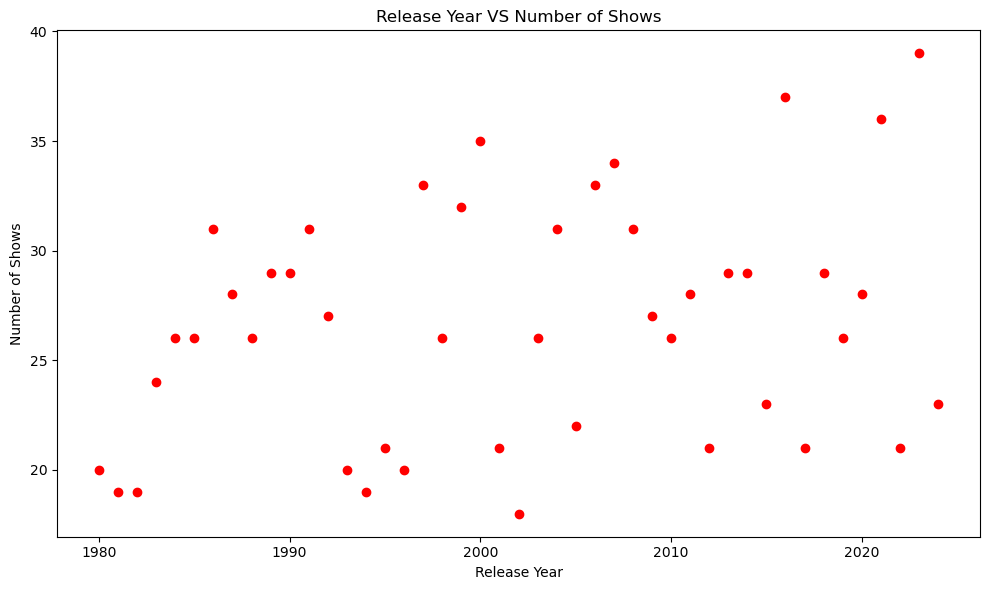

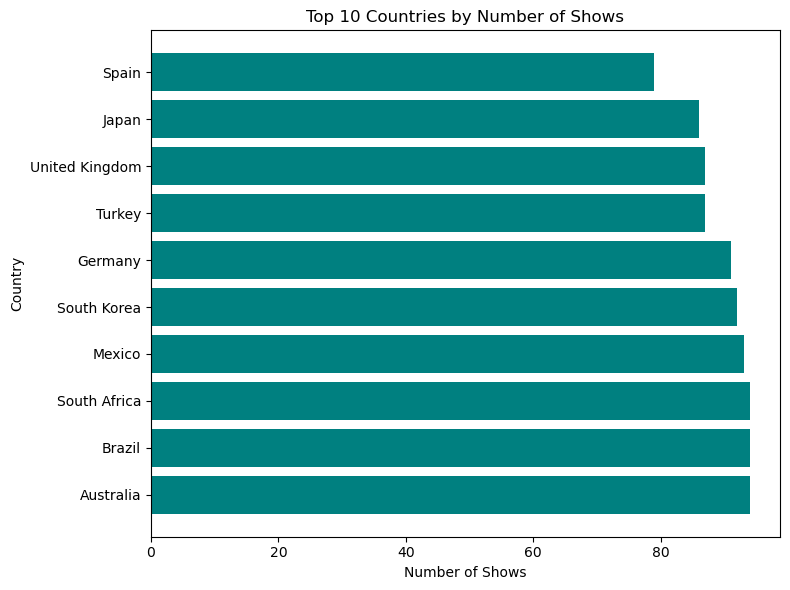

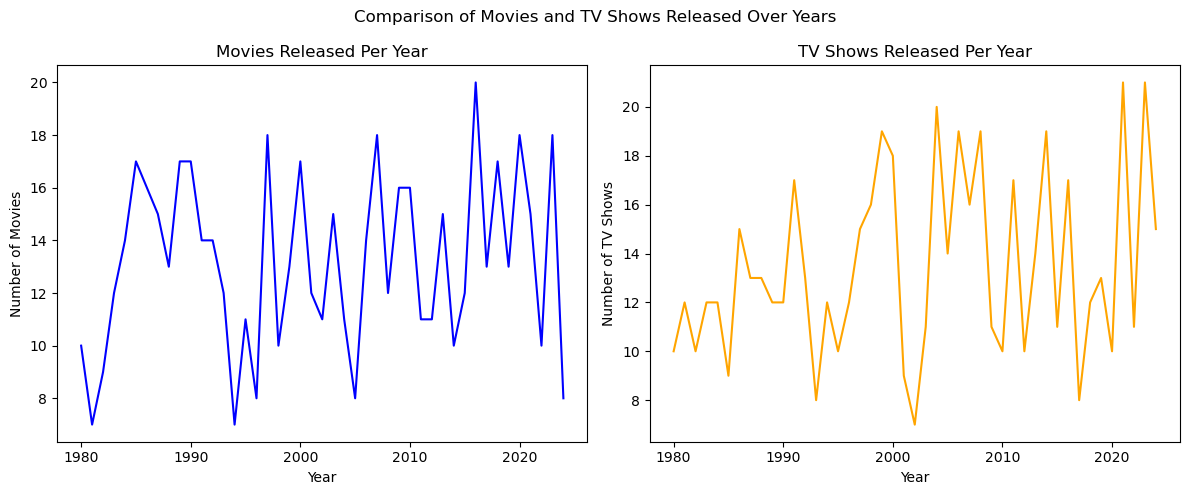

In [8]:
import pandas as pd  
import matplotlib.pyplot as plt  

# load the data 
df = pd.read_csv('Netflix_Titles.csv')
# print(df)

# clean the data 
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()


rating_counts = df['rating'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('content_Ratings_pie.png')
plt.show()

# Filter dataframe for movies and create a deep copy
# Filter only Movie records
movie_df = df[df['type'] == 'Movie'].copy()

# Convert duration (e.g., "90 min") into numeric values
movie_df['duration_int'] = (
    movie_df['duration']
    .str.replace(' min', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Remove rows with missing duration values
movie_df = movie_df.dropna(subset=['duration_int'])

# Create histogram
plt.figure(figsize=(8, 6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')

# Add title and labels
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

# Improve layout
plt.tight_layout()

# Save and display
plt.savefig('movie_duration_histogram.png')
plt.show()



# Calculate value counts for each release year and sort by year
release_counts = df['release_year'].value_counts().sort_index()

# Set up the figure size
plt.figure(figsize=(10, 6))

# Plot a scatter plot of years versus counts
plt.scatter(release_counts.index, release_counts.values, color='red')

# Add title and axis labels
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')

# Adjust layout to fit elements cleanly
plt.tight_layout()

# Save the visualization as an image file
plt.savefig('release_year_Scatter.png')

# Display the plot
plt.show()





# Get the value counts for the top 10 countries
country_counts = df['country'].value_counts().head(10)

# Set up the figure size
plt.figure(figsize=(8, 6))

# Plot a horizontal bar chart
plt.barh(country_counts.index, country_counts.values, color='teal')

# Add title and axis labels
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')

# Adjust layout to fit elements cleanly
plt.tight_layout()

# Save the visualization as an image file
plt.savefig('top10_countries.png')

# Display the plot
plt.show()






# Group data by year and type, unstack, and fill missing values with 0
# Group data by year and type, unstack, and fill missing values with 0
content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

# Create a figure with 1 row and 2 columns of subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

# Second subplot: TV Shows (Fixed subplot index, title, and label)
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('TV Shows Released Per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')

# Add an overall main title to the figure
fig.suptitle('Comparison of Movies and TV Shows Released Over Years')

# Optimize layout and save the visualization
plt.tight_layout()
plt.savefig('movies_tv_shows_comparison.png')
plt.show()


